# Derivatives

The purpose of this notebook is to review the basics of derivatives and to play around with python

In [149]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt
from matplotlib import cm

plt.style.use('default')
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 8

# 1. Intro

A derivative is a contract whose value derives from an **underlying** asset such as a stock, bond, commodity, currency, interest rate, or index.

It obligates (or give the right to) two parties on a future transaction. 

It can be negotiated between two private parties in a customized over-the-counter (**OTC**) contract or traded as a standardized contract in an exchange market.

It is used for various reasons such as:
- **hedging**: protecting against certain type of risks, such as an airline company using derivatives to lock in the future price of fuel.
- **investing**: gaining exposure to an asset price movement with less capital upfront or with limited risk, typically with a long-term view.
- **speculating**: taking bets on price movements in the financial markets to generate short-term gains.
- **arbitrage**: exploiting temporary price differences between related markets or instruments to seek profit.


### Some definitions:

- **Long position**: Holder (buyer) of the contract
- **Short position**: Seller (writer) of the contract

# 2. Forward and Futures

- A forward contract is a customized OTC agreement between two parties to buy or sell an asset at a fixed price on a specific future date.

- A futures contract is a standardized, exchange-traded agreement to buy or sell an asset at a fixed price on a specific future date.
    - They are mostly cash-settled.
    - They feature daily mark-to-market settlement with margin requirement.

### Payoff at maturity

If we denote $S_T$ as the price of the underlying at maturity and $K$ as the delivery price, the final payoff of the contract is: $$ S_T - K $$
For a short forward contract we have: $$ K - S_T $$
For example, if $K = 100$  we have:

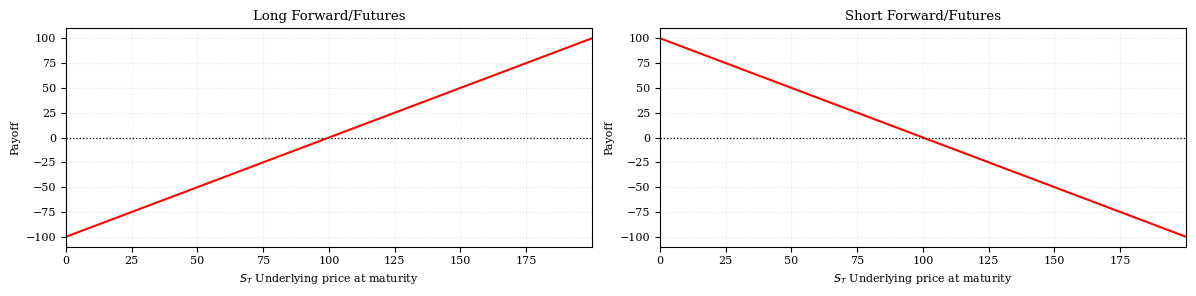

In [150]:
S = np.arange(0,200, 0.01)
K = 100

def plot_forward(ax, S, payoff, title):
    ax.plot(S, payoff,'r')
    ax.axhline(0, color='black', linewidth=0.9, linestyle=':')

    ax.grid(linestyle=':', alpha=0.3)
    ax.margins(x=0)
    ax.set_xlabel('$S_T$ Underlying price at maturity')
    ax.set_ylabel('Payoff')
    ax.set_title(title)

fig, axs = plt.subplots(1,2, figsize=(12, 3))

plot_forward(axs[0], S, S-K, 'Long Forward/Futures')
plot_forward(axs[1], S, K-S, 'Short Forward/Futures')
plt.tight_layout()
plt.show()

## Valuation

### Principle of time value of money and risk free interest rate

- **Time value of money**: 1 CHF today is worth more than 1 CHF in the future due to its potential earning opportunity today. [Wiki](https://en.wikipedia.org/wiki/Time_value_of_money)
- **Risk free rate**: The theoretical return on an investment with zero default risk, used as a baseline for valuing all assets.
    - Good proxies in Switzerland include **SARON** or yields on Swiss government bonds.

#### Calculation with interest rate
$P$ = principal, $r$ = interest rate and $t$ = time
- **Simple interest**: Interest earned only on the initial principal, no interest on interest: $ P \times (1+ rt) $
- **Compound interest**: Interest earned on principal + previously accrued interest, at discrete intervals:
$ P \times (1 + r/n)^{nt} $,
where $n$ = compounds per year
- **Continuous compounding**: The limit as the compounding frequency, $n$, tends to infinity: $ P e^{rt} $

#### Time value of money
- Future value of money:
    
    - Investing 100 CHF at a risk free rate of 3% (for illustration as [SNB rates](https://www.snb.ch/en/the-snb/mandates-goals/statistics/statistics-pub/current_interest_exchange_rates#t00) are ~0% in 2026) for 5 years yields: 
    $$ FV = 100 \times (1+0.03)^5 = 100 \times 1.1593 = 115.93 $$

- Present value of money:
    - To reverse the relationship and find today's value of a future cash flow, we *discount* it back using the risk-free rate. 
    
        Example: what is 100 CHF in 5 years worth today at 3% ?
        $$ PV = \frac{100}{(1 + 0.03)^5} = 100 \times (1+0.03)^{-5} = 86.26 $$

(todo a notebook about bonds ..)

### Fair delivery price

Let's consider a forward contract on a non-paying dividend and without storage cost with delivery price $F$.

The value of the contract at maturity with payoff $S_T - F$ can be constructed as a portfolio composed of a stock and the same value invested in a risk-free asset.

- The stock has value $S_t$ today and $S_T$ at maturity
- A risk-free investment equal to $F$ at maturity is equal to $Fe^{-r(T-t)}$ today.

At $T$, the portfolio has a value $S_T - F$ and today at $t$, the value is equal to $S_t - Fe^{-r(T-t)}$.

At inception, the value of the contract is zero (no money exchanged, no premiums for both parties), therefore $S_t = Fe^{-r(T-t)}$ which implies $$ F_t = S_te^{r(T-t)} $$

$F_t$ refers to the forward price computed at time $t$

### No arbitrage principle

We always assume there is no arbitrage opportunity when calculating theoretical prices of an asset. We say there is an arbitrage when we
can obtain a strictly positive benefit without risk out of nothing. There is no free-lunch.

Basic principle in finance to take advantage of price discrepancies: Sell high, buy low.

Example: Consider a long forward contract to purchase a stock in 3 months. Assume the current stock price is 40 CHF and the 3-month risk-free interest
rate is 5% per annum. The fair price of the forward would be $ 40 \times e^{0.05 \times 3/12}  = 40.46 $. What happen when the price of the forward is not correct?

1) If the forward price is relatively high at 43 CHF
    - Action today:
        - An arbitrageur can borrow 40CHF at 5% for 3 months
        - Buy the asset for 40 CHF
        - Enter into a forward contract to sell the asset for 43 CHF in 3 months
    - Action in 3 months:
        - Sell the asset for 43 CHF
        - Repay the loan with interest of 40.46 CHF
    - Profit:
        $ 43 - 40.46 = 2.54 $

2) If the forward price is relatively low at 39 CHF
    - Action today:
        - An arbitrageur can short-sell the asset for 40 CHF
        - Invest 40 CHF at 5% for 3 months
        - Enter into a forward contract to buy the asset for 39 CHF in 3 months
    - Action in 3 months:
        - Buy the asset for 39 CHF
        - Close short position
        - Receive 40.46 CHF from investment
    - Profit:
        $ 40.46 - 39 = 1.46 $
    
We deduce that, for there to be no arbitrage opportunities, the forward price must be excatly 40.46 CHF.

# 3. Options

- **Call** options are contract that give the right but not the obligation to the owner to **buy** an underlying asset at some prefix price $K$, the **strike price** at some moment in the future.
- **Put** options are contract that give the right but not the obligation to the owner to **sell** an underlying asset at some prefix price $K$, the **strike price** at some moment in the future.
- An option that can be exercised only at expiry is an **European** option whereas if it can be exercised at anytime before expiration is called an **American** option.

## Payoff
At expiration date $T$, for a given underlying price $S_T$ and a strike price $K$

- The payoff of a Long Call Option is given by $ max(S_T - K, 0 ) $
- The payoff of a Long Put Option is given by $ max(K - S_T, 0) $
- The payoff of a Short Call Option is given by $ - max(S_T - K, 0) $
- The payoff of a Short Put Option is given by $ - max(K-S_T, 0) $

## Moneyness of an option
An intrinsic value of an option is the value it would have if the option is exercised immediately at time $t$ without taking into account the time value. If its value is positive the option is

- in the money **ITM**
    - for a call options: if $S_t > K$
    - for a put option: if $S_t < K$

if its intrinsic value is null the option is
- out-of-the-money **OTM**
    - for a call option: if $S_t < K$
    - for a put option: if $S_t > K$

- at-the-money **ATM** if $S_t = K$

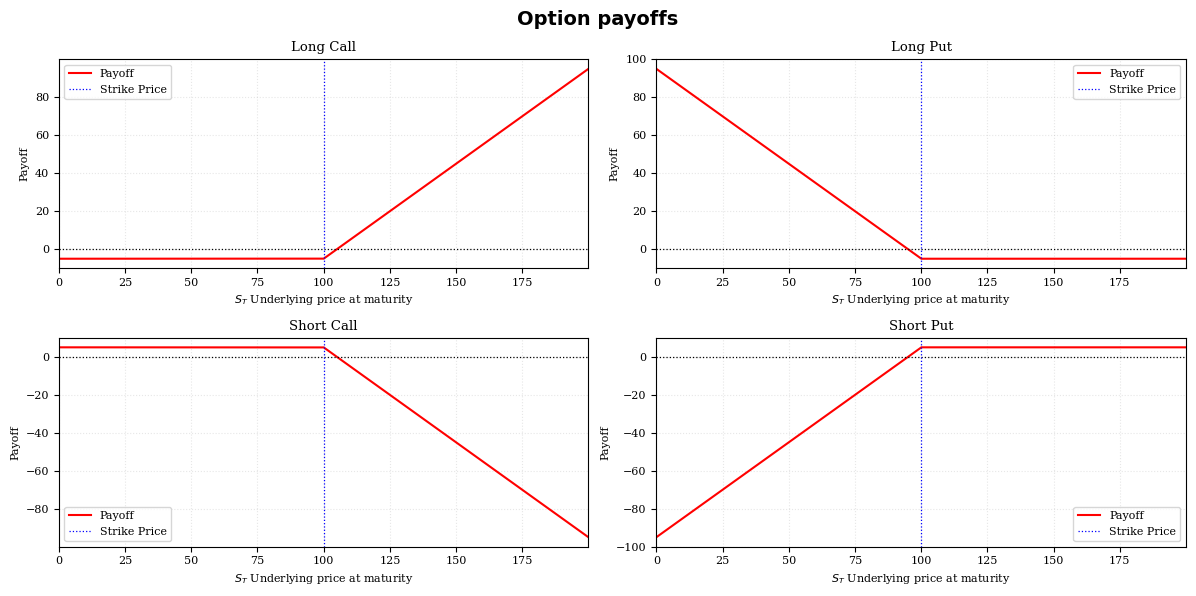

In [151]:
def long_call(S, K, premium):
    c = np.maximum(S-K, 0) - premium
    return c

def long_put(S, K, premium):
    p = np.maximum(K-S, 0) - premium
    return p

def plot_options(ax, S, payoff, title):
    ax.plot(S, payoff,'r', label='Payoff')
    ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
    ax.axvline(K, color='blue', linewidth=0.9, linestyle=':', label='Strike Price')
    ax.grid(linestyle=':', alpha=0.3)
    ax.margins(x=0)
    ax.set_xlabel('$S_T$ Underlying price at maturity')
    ax.set_ylabel('Payoff')
    ax.set_title(title)
    ax.legend()

S = np.arange(0, 200, 0.01)
K = 100
premium = 5

fig, axs = plt.subplots(2, 2, figsize=(12,6))

plot_options(axs[0][0], S, long_call(S,K, premium), 'Long Call')
plot_options(axs[0][1], S, long_put(S,K, premium), 'Long Put')
plot_options(axs[1][0], S, -long_call(S,K, premium), 'Short Call')
plot_options(axs[1][1], S, -long_put(S,K, premium), 'Short Put')

plt.suptitle("Option payoffs", fontweight='bold', fontsize=14, fontfamily='sans-serif')
plt.tight_layout()
plt.show()

Standard American and European call and put options are known as *plain vanilla options*. 

Beyond these, a wide variety of *exotic options* exist. Here are a few examples:

## Binary options

A binary or digital *cash-or-nothing* option pays a fixed amount $Q$ at expiry if it ends up in the money, otherwise nothing.

$$
\text{Payoff of a binary CALL option} = 
\begin{cases} 
Q & \text{if } S_T > K \\
0 & \text{if } S_T \leq K 
\end{cases}
$$

$$
\text{Payoff of a binary PUT option} = 
\begin{cases} 
Q & \text{if } S_T < K \\
0 & \text{if } S_T \geq K 
\end{cases}
$$

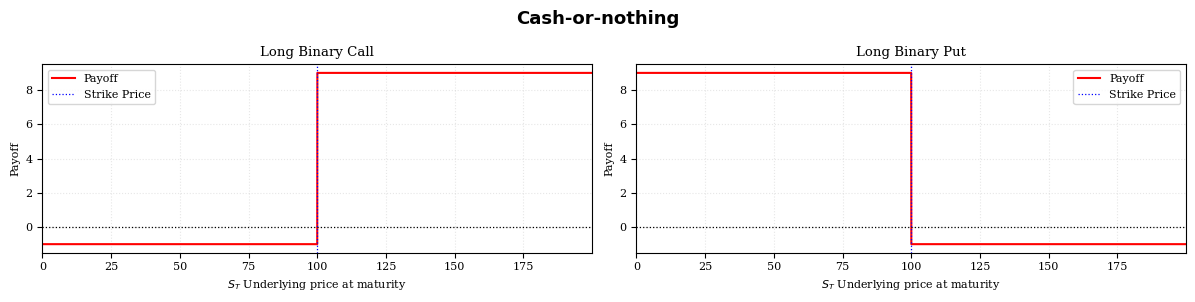

In [167]:
def binary_call(S, K, Q, premium):
    bc = Q*np.where(S>K, 1, 0) - premium
    return bc

def binary_put(S, K, Q, premium):
    bp = Q*np.where(S<K, 1, 0) - premium
    return bp

S = np.arange(0, 200, 0.01)
K = 100
Q = 10
premium = 1

fig, axs = plt.subplots(1, 2, figsize=(12,3))

plot_options(axs[0], S, binary_call(S, K, Q, premium), 'Long Binary Call')
plot_options(axs[1], S, binary_put(S, K, Q, premium), 'Long Binary Put')
plt.suptitle('Cash-or-nothing', fontweight='bold', fontsize=13, fontfamily='sans-serif')
plt.tight_layout()

Another variant is and *asset-or-nothing* option that gives the holder to receive the final value of the underlying asset $S_T$ if the option expires ITM.

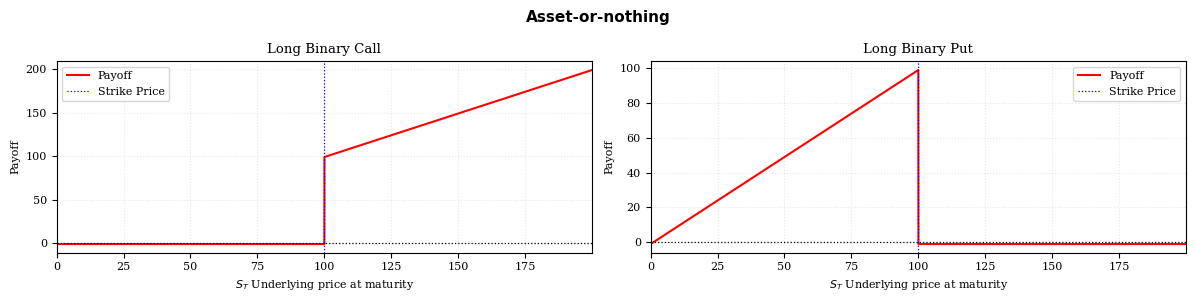

In [153]:
S = np.arange(0, 200, 0.01)
K = 100
premium = 1

fig, axs = plt.subplots(1, 2, figsize=(12,3))

plot_options(axs[0], S, binary_call(S, K, S, premium), 'Long Binary Call')
plot_options(axs[1], S, binary_put(S, K, S, premium), 'Long Binary Put')
plt.suptitle('Asset-or-nothing', fontweight='bold', fontsize=11, fontfamily='sans-serif')

plt.tight_layout()

## Barrier options

Barrier options are options where the payoff depends on whether the underlying asset reaches a certain level during a period of time.

There are four main types of barrier options:

- **Up and Out**: price of the underlying starts below the barrier, if it goes up and reaches the barrier, the option becomes worthless (knocked out)
- **Down and Out**: price of the underlying starts above the barrier, if it goes down and reaches the barrier, the option becomes worthless (knocked out)
- **Up and In**: price of the underlying starts below the barrier, if it goes up and reaches the barrier, the option is activated (knocked in)
- **Down and In**: price of the underlying starts above the barrier, if it goes down and reaches the barrier, the option is activated (knocked in)

Example of simulated price paths for an underlying asset in which the down-and-in barrier is triggered.

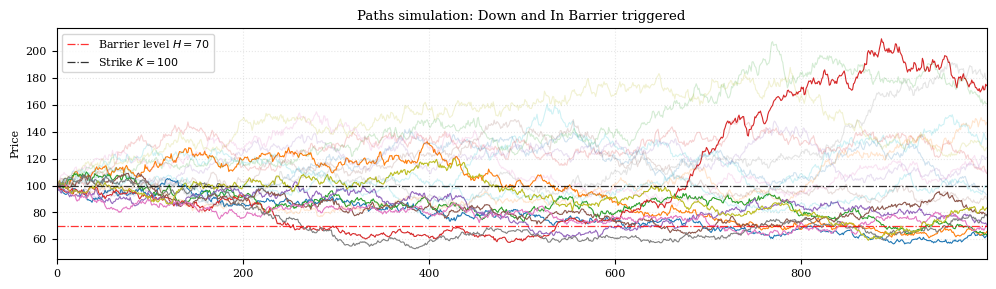

In [154]:
S0=100; mu=0; sigma=0.4; T=1.0; n_steps=1000; n_sims=20; dt=T/n_steps
np.random.seed(15)
S_T = S0 * np.cumprod(np.exp( (mu-sigma**2/2)*dt + sigma*np.sqrt(dt)*(np.random.standard_normal((n_sims, n_steps)))), axis=1)

barrier=70
K=100
down_in_filter = np.any(S_T < barrier, axis=1)

plt.figure(figsize=(12,3))
plt.plot(S_T[down_in_filter].T, linewidth=0.8)
plt.plot(S_T[~down_in_filter].T, linewidth=0.8, alpha=0.2)
plt.axhline(y=barrier, linestyle=":", color = 'r', ls= '-.', alpha=0.8, lw=0.9, label=f'Barrier level $H={barrier}$')
plt.axhline(y=K, linestyle=":", color = 'black', ls= '-.', alpha=0.8, lw=0.9, label=f'Strike $K={K}$')

plt.grid(linestyle=':', alpha=0.3)
plt.margins(x=0)
plt.legend()
plt.ylabel('Price')
plt.title('Paths simulation: Down and In Barrier triggered')

plt.show()

We observe that the red path touches the barrier, but ends well above the strike price. The down-and-in barrier activates the option, yet it finishes out of the money for a put option.

Example of payoffs for a Down and In Put option and a Down and Out Put option:

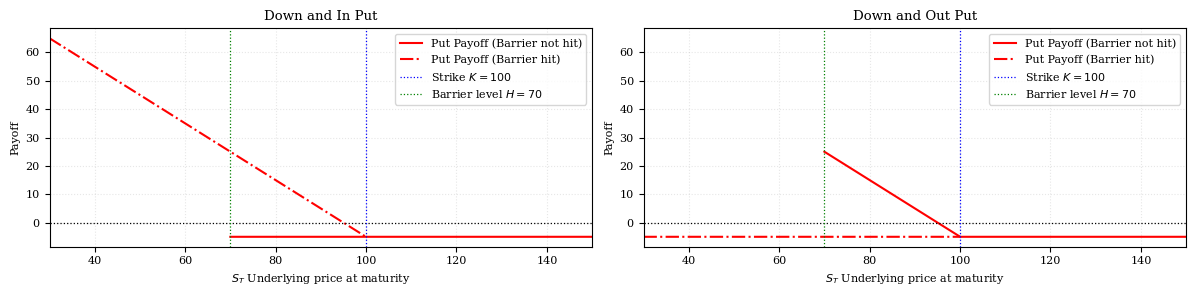

In [155]:
K = 100
H = 70
premium = 5
S = np.arange(30,150,0.01)

def plot_barrier_down_put(ax, S, K, H, premium, title, what):
    if what == "down_in":
        S_IN = S[S<K] 
        S_OUT = S[S>H]
        ax.plot(S_OUT, -premium*np.ones_like(S_OUT), 'r', label='Put Payoff (Barrier not hit)')
        ax.plot(S_IN, long_put(S_IN, K, premium),'r-.', label='Put Payoff (Barrier hit)')
    elif what == "down_out":
        S_OUT = S[S<K]
        S_IN = S[S>H]
        ax.plot(S_IN, long_put(S_IN, K, premium), 'r', label='Put Payoff (Barrier not hit)')
        ax.plot(S_OUT, -premium * np.ones_like(S_OUT), 'r-.', label='Put Payoff (Barrier hit)')

    ax.axhline(y=0, c='black', linewidth=0.9, linestyle=':')
    ax.axvline(x=K, c='blue', linewidth=0.9, linestyle=':', label=f'Strike $K={K}$')
    ax.axvline(x=H, c='green', linewidth=0.9, linestyle=':', label=f'Barrier level $H={H}$')
    ax.tick_params(labelleft=True)
    ax.grid(linestyle=':', alpha=0.3)
    ax.margins(x=0)
    ax.set_ylabel('Payoff')
    ax.set_xlabel('$S_T$ Underlying price at maturity')
    ax.legend()
    ax.set_title(title)


fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
plot_barrier_down_put(axs[0], S, K, H, premium, 'Down and In Put', 'down_in')
plot_barrier_down_put(axs[1], S, K, H, premium, 'Down and Out Put', 'down_out')
plt.tight_layout()
plt.show()

### Combinations of options

It is also possible to combine multiple calls and puts with different strike prices or expiration date on the same underlying asset in order to take advantage of different market conditions. Here are some popular strategies using different strike prices.

In [156]:
def plot_options_combination(ax, S, payoff1, label1, payoff2, label2, combined, label3):
    ax.plot(S, payoff1, 'r-.', linewidth=0.9, label=label1)
    ax.plot(S, payoff2, 'b-.', linewidth=0.9, label=label2)
    ax.plot(S, combined, 'r')
    ax.axhline(0, color='black', linewidth=0.9, linestyle=':')

    ax.set_title(label3 + "\n", fontweight='bold', fontsize=11, fontfamily='sans-serif')
    ax.text(0.5, 1.02, label1 + ", " + label2, ha="center", va="bottom", fontsize=9, transform=ax.transAxes)

    ax.set_xlabel('$S_T$ Underlying price at maturity')
    ax.set_ylabel('Payoff')
    ax.grid(linestyle=':', alpha=0.3)
    ax.legend()
    ax.margins(x=0)

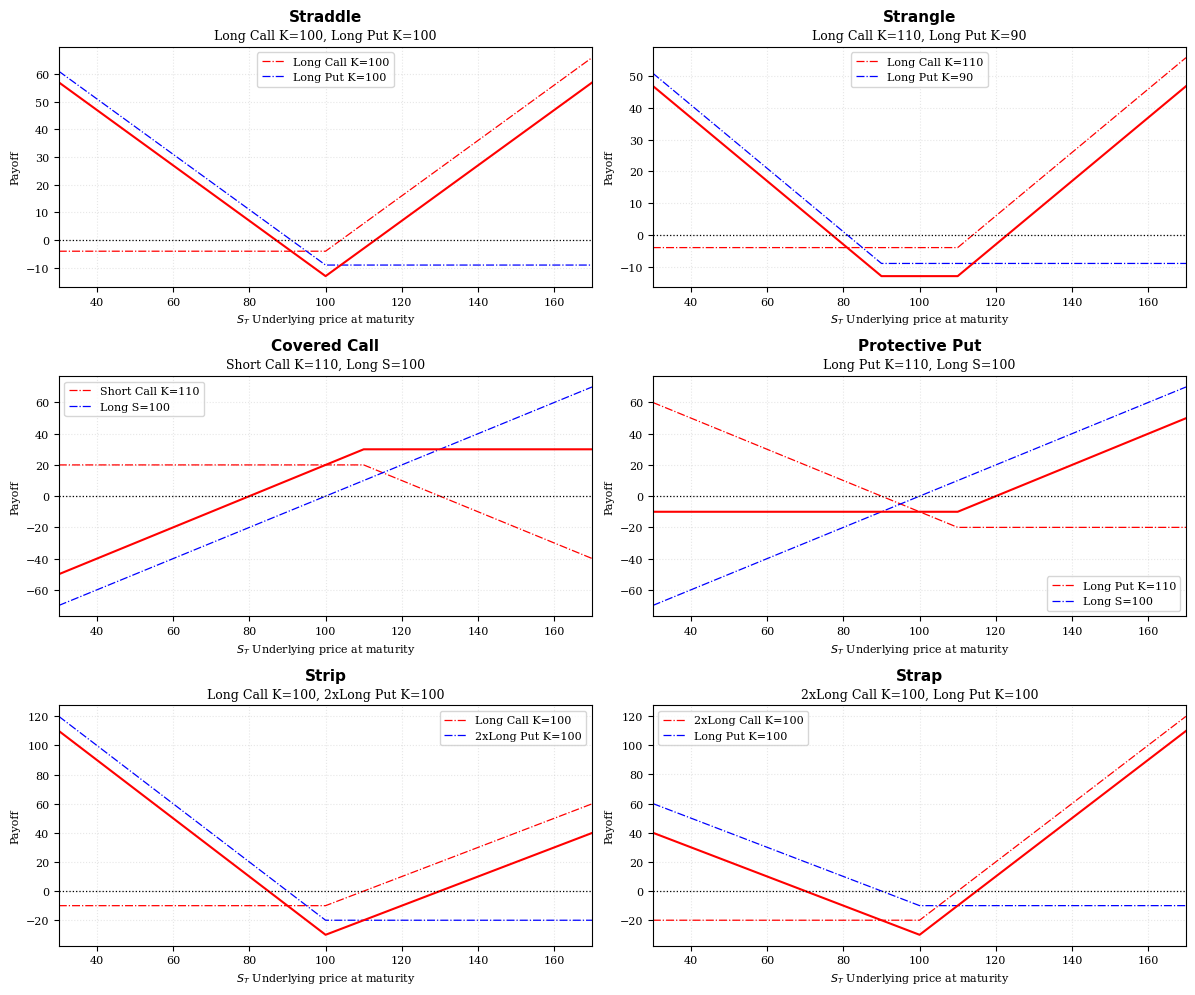

In [157]:
S = np.arange(30, 170, 0.1)

fig, axs = plt.subplots(3,2, figsize=(12,10))

# Straddle
K = 100
lc = long_call(S, K, 4)
lp = long_put(S, K, 9)
plot_options_combination(axs[0,0], S, lc, f'Long Call K={K}', lp, f'Long Put K={K}', lp+lc, 'Straddle')

#Strangle
lc = long_call(S, 110, 4)
lp = long_put(S, 90, 9)
plot_options_combination(axs[0,1], S, lc, 'Long Call K=110', lp, 'Long Put K=90', lp+lc, 'Strangle')

#Covered Call
sc = -long_call(S, 110, 20)
plot_options_combination(axs[1,0], S, sc, 'Short Call K=110', S-100, 'Long S=100', S-100+sc, 'Covered Call')

# Protective Put
lp = long_put(S, 110, 20)
plot_options_combination(axs[1,1], S, lp, 'Long Put K=110', S-100, 'Long S=100', S-100+lp, 'Protective Put')

# Strip
lc = long_call(S,100,10)
lp = long_put(S, 100, 10)
plot_options_combination(axs[2,0], S, lc, 'Long Call K=100', 2*lp, '2xLong Put K=100', lc+lp+lp, 'Strip')

# Strap
lc = long_call(S, 100, 10)
lp = long_put(S, 100, 10)
plot_options_combination(axs[2,1], S, 2*lc, '2xLong Call K=100', lp, 'Long Put K=100', lc+lc+lp, 'Strap')

plt.tight_layout()
plt.show()

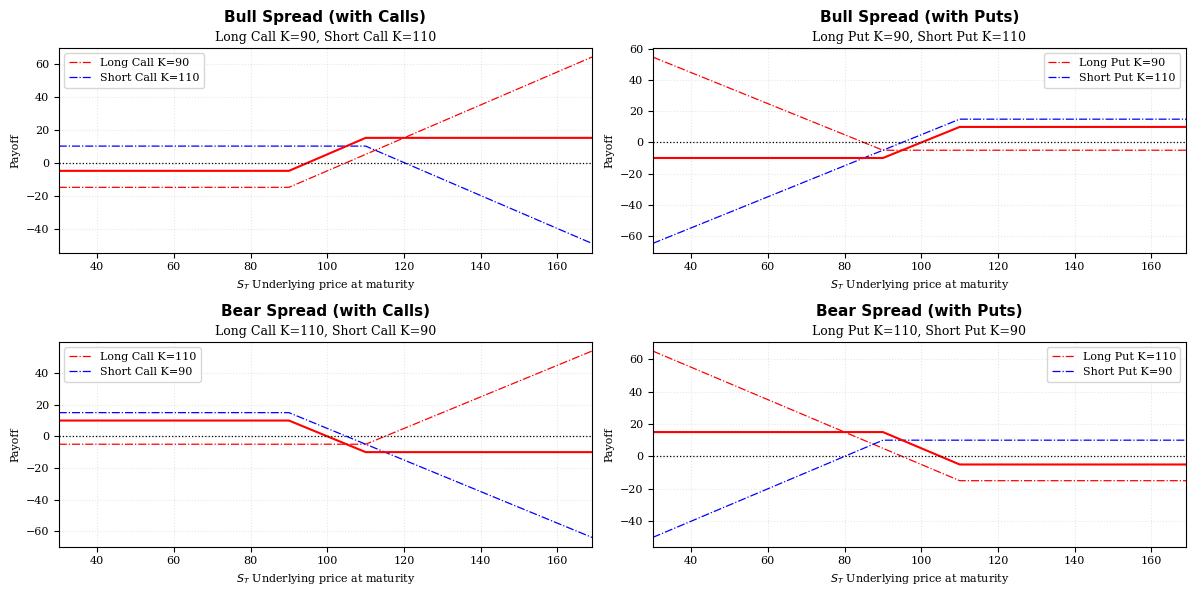

In [158]:
S = np.arange(30, 170, 1)

fig, axs = plt.subplots(2,2, figsize=(12,6))

# Bull spread
lc = long_call(S, 90, 15)
sc = -long_call(S,110, 10)
plot_options_combination(axs[0,0], S, lc, 'Long Call K=90', sc, 'Short Call K=110', lc+sc, 'Bull Spread (with Calls)')

# Bull spread PUT
lp = long_put(S, 90, 5)
sp = -long_put(S, 110, 15)
plot_options_combination(axs[0,1], S, lp, 'Long Put K=90', sp, 'Short Put K=110', lp+sp, 'Bull Spread (with Puts)')

# Bear Spread
lc = long_call(S, 110, 5)
sc = -long_call(S, 90, 15)
plot_options_combination(axs[1,0], S, lc, 'Long Call K=110', sc, 'Short Call K=90', lc+sc, 'Bear Spread (with Calls)')

lp = long_put(S, 110, 15)
sp = -long_put(S, 90, 10)
plot_options_combination(axs[1,1], S, lp, 'Long Put K=110', sp, 'Short Put K=90', lp+sp, 'Bear Spread (with Puts)')

plt.tight_layout()

### Black Scholes Merton 

The Black-Scholes model prices European options using a closed-form formula derived from a no-arbitrage partial differential equation. It assumes stock prices follow geometric Brownian motion under risk-neutral dynamics.
$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = rV$$
where:
- $V$ = option price
- $S$ = underlying price  
- $t$ = time
- $r$ = risk-free rate
- $\sigma$ = volatility

A closed-formed formula for a **European Call** option is:

$$
C(S_0, K, T, r, \sigma) = S_0 \mathcal{N}(d_1) - K e^{-rT} \mathcal{N}(d_2)
$$

For a **Europen Put** option: 

$$
P(S_0, K, T, r, \sigma) = K e^{-rT} \mathcal{N}(-d_2) - S_0 \mathcal{N}(-d1)
$$

where
$$
d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}},  \quad

d_2 = d_1 - \sigma\sqrt{T}
$$

and

- $S_0$: current stock price
- $K$: strike price
- $r$: risk-free rate
- $\sigma$: volatility
- $T$: time to expiry
- $\mathcal{N}(.)$: cumulative normal distribution



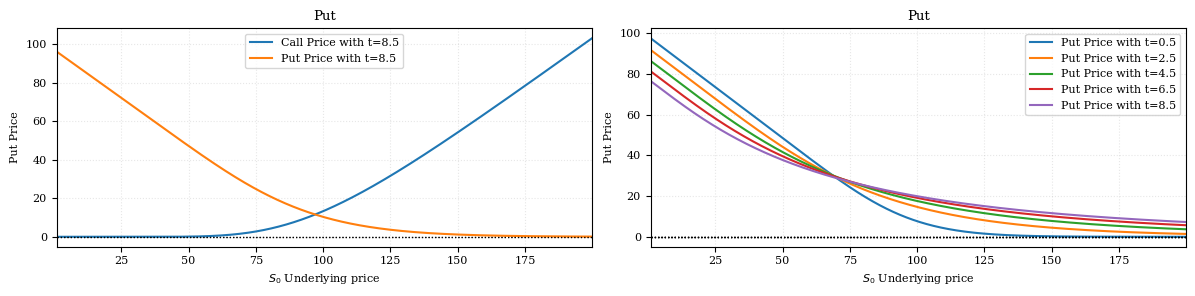

In [174]:
def d1(S, K, T, r, sigma):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma*np.sqrt(T)

def N(x):
    return norm.cdf(x)

def BSM_call(S, K, T, r, sigma):
    x1 = d1(S, K, T, r, sigma)
    x2 = d2(S, K, T, r, sigma)
    return S*N(x1) - K*np.exp(-r*T)*N(x2)

def BSM_put(S, K, T, r, sigma):
    x1 = d1(S, K, T, r, sigma)
    x2 = d2(S, K, T, r, sigma)
    return K*np.exp(-r*T)*N(-x2) - S*N(-x1)

def plot_option_price(ax, S, payoff, title):
    ax.plot(S, payoff, label=f'{title} Price with t={t}')
    ax.axhline(0, color='black', linewidth=0.9, linestyle=':')
    ax.grid(linestyle=':', alpha=0.3)
    ax.margins(x=0)
    ax.set_xlabel('$S_0$ Underlying price')
    ax.set_ylabel(f'{title} Price')
    ax.set_title(title)
    ax.legend()

S = np.arange(1, 200, 0.1)
K = 100
T = 1.0
r = 0.03
sigma = 0.3
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

plot_option_price(axs[0], S, BSM_call(S, K, T, r, sigma), 'Call')
plot_option_price(axs[0], S, BSM_put(S, K, T, r, sigma), 'Put')

T = np.arange(0.5,10.0, 2)
for t in T:
    plot_option_price(axs[1], S, BSM_put(S, K, t, r, sigma), 'Put')

plt.tight_layout()

### Barrier Reverse Convertible

A barrier reverse convertible (BRP) is a structured product that combines a fixed coupon bond with an embeded down-and-in put option on an underlying asset.

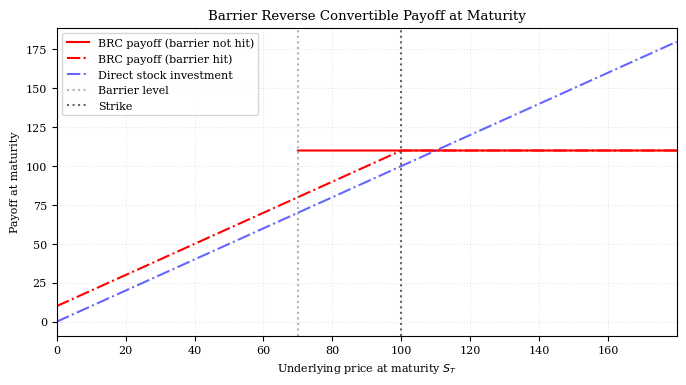

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100.0      # nominal
K = 100.0      # strike
B = 70.0       # barrier level (not used directly in terminal-only payoff,
               # but relevant for labeling the plot)
c = 0.1        # coupon rate

# Range of underlying prices at maturity
S_T = np.arange(0, 180, 0.1)
S_NOHIT = np.arange(B, 180, 0.1)
# Scenario 1: barrier NOT hit (capital protection holds)
# Investor always gets nominal + coupon
# payoff_no_hit = np.full_like(S_T, N * (1 + c))


payoff_no_hit = np.where(S_T < B, (S_T / K) * N + N * c, N * (1 + c))

# Scenario 2: barrier hit during life
payoff_hit = np.where(
    S_T >= K,
    N * (1 + c),          # stock recovers above strike, par + coupon
    (S_T / K) * N + N * c # stock below strike, physical delivery + coupon
)

# Underlying (direct equity) payoff for reference
equity_payoff = S_T  # assuming you invest N=100 directly in the stock

# Plot
plt.figure(figsize=(8, 4))
plt.plot(S_NOHIT, (N * (1 + c)) * np.ones_like(S_NOHIT), 'r', label='BRC payoff (barrier not hit)')
plt.plot(S_T, payoff_hit, 'r', label='BRC payoff (barrier hit)', linestyle="-.")
plt.plot(S_T, equity_payoff, 'b-.', label='Direct stock investment', alpha=0.6)

plt.axvline(B, color='grey', linestyle=':', label='Barrier level', alpha=0.6)
plt.axvline(K, color='black', linestyle=':', label='Strike', alpha=0.6)

plt.xlabel('Underlying price at maturity $S_T$')
plt.ylabel('Payoff at maturity')
plt.title('Barrier Reverse Convertible Payoff at Maturity')
plt.legend()
plt.grid(linestyle=':', alpha=0.3)
plt.margins(x=0)
plt.show()

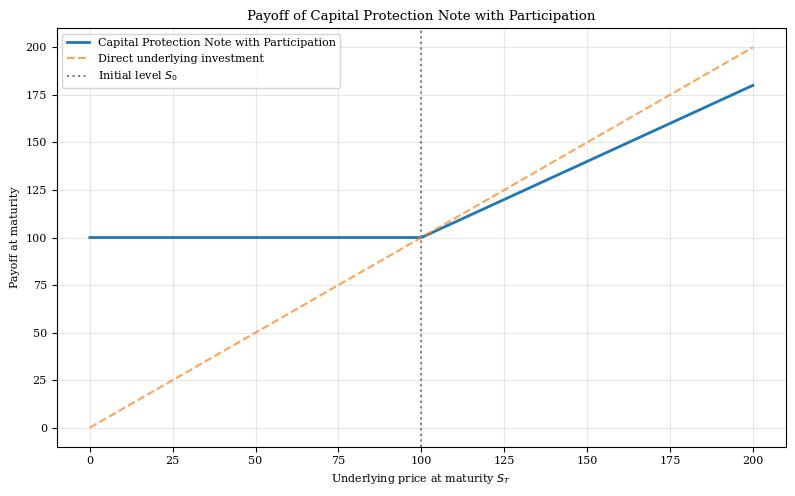

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100.0        # nominal
CP = 1.0         # capital protection level (100%)
p = 0.8          # participation rate (80%)
S0 = 100.0       # initial underlying level

# Range of underlying prices at maturity
S_T = np.linspace(0, 200, 1001)
Pi = (S_T - S0) / S0  # performance

# Payoff formula
payoff = N * np.maximum(CP, CP + p * Pi)

# For comparison: direct underlying investment
underlying_payoff = N * (S_T / S0)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(S_T, payoff, label='Capital Protection Note with Participation', linewidth=2)
plt.plot(S_T, underlying_payoff, label='Direct underlying investment', linestyle='--', alpha=0.7)

plt.axvline(S0, color='grey', linestyle=':', label='Initial level $S_0$')
plt.xlabel('Underlying price at maturity $S_T$')
plt.ylabel('Payoff at maturity')
plt.title('Payoff of Capital Protection Note with Participation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Options

What is an option

Definitions

### References
https://clinthoward.github.io/portfolio/2017/04/16/BlackScholesGreeks/

https://github.com/AmirDehkordi/OptionGreeks/blob/main/Option_Greeks.ipynb

https://github.com/cwei-suse/Python-resource/blob/master/Derivatives%20Analytics%20with%20Python.pdf

https://www.codearmo.com/python-tutorial/options-trading-greeks-black-scholes

https://clinthoward.github.io/portfolio/2017/04/16/BlackScholesGreeks/


## Black Scholes



### Barriere Reverse Convertible

- If barrier never hit: $ N+ N*coupon $
- If barrier hit and $ S_T >= K $ : $ N + N* coupon$
- If barrier hit and $ S_T < K : N/K* S_T + N*coupon $

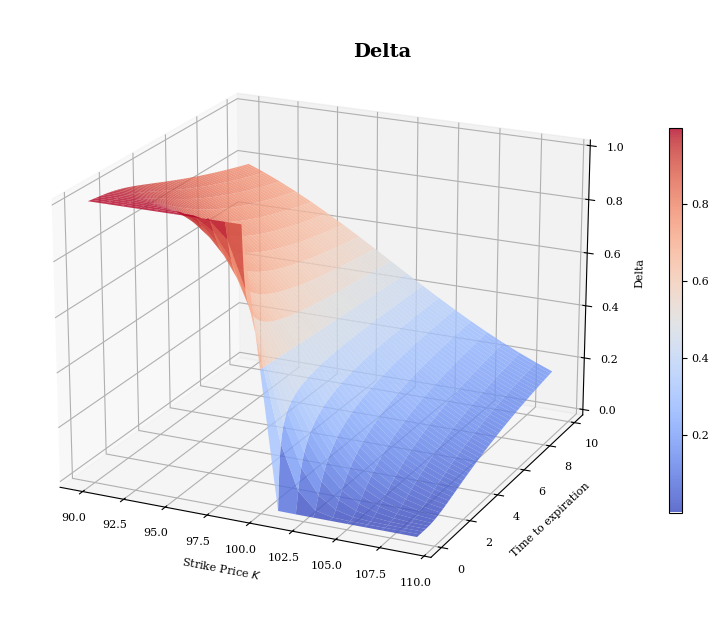

In [ ]:
def delta(S, K, t, r, sigma):
    try:
        d1 = (np.log(S/K) + t*(r*sigma**2 / 2)) / (sigma * np.sqrt(t))
        deltaCall = np.exp(-r*t)*norm.cdf(d1)
        return deltaCall
    except:
        print('Error, t negative')

def BS_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r  + 0.5*sigma**2)*T) / (sigma*T)
    d2 = d1 - sigma*T
    return S*norm.cdf(d1) - norm.cdf(d2)*K*np.exp(-r*T)


s = np.arange(90, 110, 1)
t = np.arange(0.01, 10, 0.05)
S, T = np.meshgrid(s, t)

K = 100; sigma = 0.03; r = 0.01
deltas = np.zeros(S.shape)
calls = np.zeros(S.shape)
for i, tt in enumerate(t):
    for j, ss in enumerate(s):
        deltas[i,j] = delta(100, ss, tt, r, sigma)
        calls[i,j] = BS_call(ss, K, tt, r, sigma)

fig = plt.figure(figsize=(10,10))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(S, T, deltas, cmap=cm.coolwarm, alpha=0.8)
plt.colorbar(surf, shrink=0.5, aspect=30)
# ax.contour(S, T, deltas, zdir='y', offset=3, cmap='coolwarm')


ax.set_xlabel('Strike Price $K$')
ax.set_ylabel('Time to expiration')
ax.set_zlabel('Delta')
ax.view_init(elev=20, azim=-65, roll=0)
ax.set_title("Delta", fontsize=14, fontweight="bold", x = 0.6, y = 0.99)

plt.show()

https://www.quantconnect.com/learning/articles/

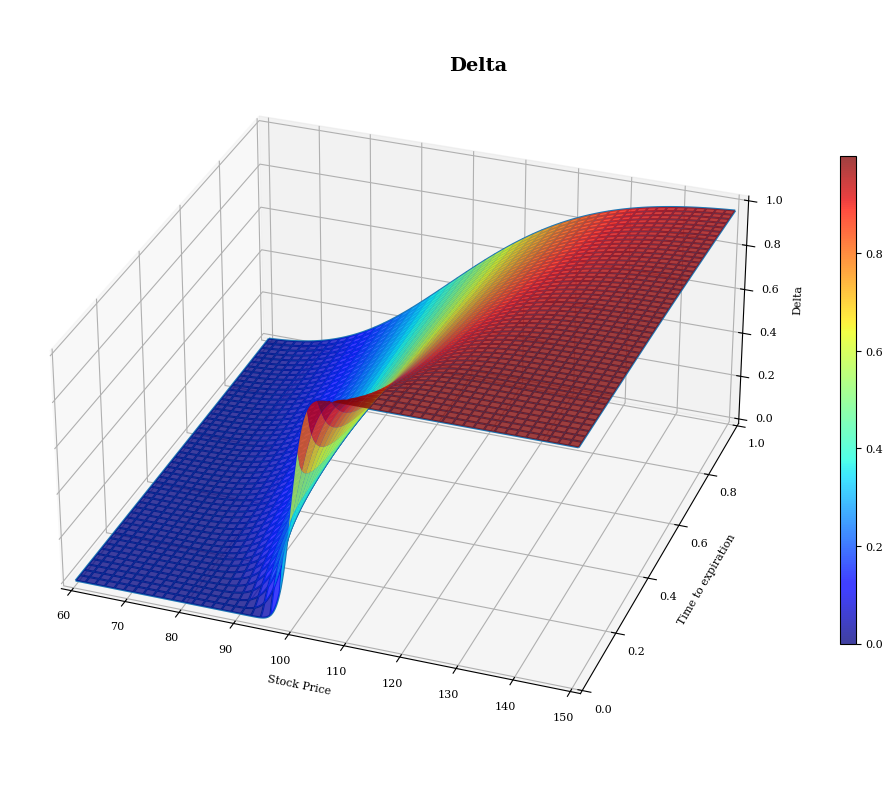

In [284]:
def delta(S, K, t, r, sigma):
    try:
        d1 = (np.log(S/K) + t*(r*sigma**2 / 2)) / (sigma * np.sqrt(t))
        deltaCall = np.exp(-r*t)*norm.cdf(d1)
        return deltaCall
    except:
        print('Error, t negative')

def BS_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r  + 0.5*sigma**2)*T) / (sigma*T)
    d2 = d1 - sigma*T
    return S*norm.cdf(d1) - norm.cdf(d2)*K*np.exp(-r*T)


s = np.arange(60, 150, 0.1)
t = np.arange(0.01, 1.0, 0.01)
S, T = np.meshgrid(s, t)

K = 100; sigma = 0.2; r = 0.01
deltas = delta(S, K, T, r, sigma)

fig = plt.figure(figsize=(10,10))
# ax = plt.axes(projection='3d')
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(S, T, deltas)
surf = ax.plot_surface(S, T, deltas, cmap=cm.jet, alpha=0.75)
plt.colorbar(surf, shrink=0.5, aspect=30)
# ax.contour(S, T, deltas, zdir='y', offset=3, cmap='coolwarm')

ax.set_box_aspect([2,2,1])

ax.set_xlabel('Stock Price')
ax.set_ylabel('Time to expiration')
ax.set_zlabel('Delta')
ax.view_init(elev=30, azim=290, roll=0)
ax.margins(0,0,0)
ax.set_title("Delta", fontsize=14, fontweight="bold", x = 0.6, y = 0.99)
plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (200,) and (20,)

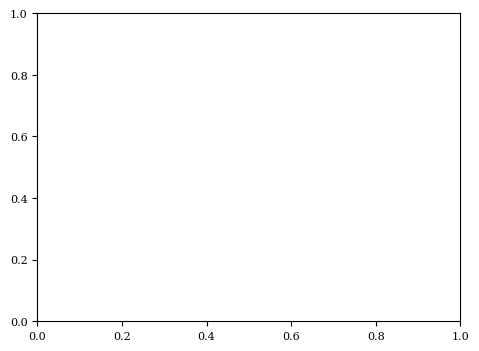

In [ ]:
fig = plt.figure(figsize=(12,4))

# fig = plt.figure(figsize=(10,4))
ax2d = fig.add_subplot(1,2,1)
for i in range(0, calls.shape[0],10):
    ax2d.plot(S[i,:], calls[i,:], label=f'T = {i/10}')
ax2d.set_xlabel("Underlying  $S_0$")
ax2d.set_ylabel('Call Price')
ax2d.grid(linestyle=":")
ax2d.legend()
# axs[1].set_title('Call')

# fig = plt.figure(figsize=(10,10))
ax3d = fig.add_subplot(1,2,2, projection='3d')
surf = ax3d.plot_surface(S, T, calls, cmap=cm.coolwarm, alpha=0.9, linewidth = 0)
fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=30)

ax3d.set_xlabel('Underlying Price')
ax3d.set_ylabel('Time to Maturity')
ax3d.set_zlabel('Call Price')
ax3d.view_init(elev=30, azim=-75, roll=0)
fig.subplots_adjust(left=0.08, wspace=0.0)

# axs[0].set_title("Call", fontsize=14, fontweight="bold", x = 0.6, y = 0.99)

# plt.show()


plt.tight_layout()
plt.show()

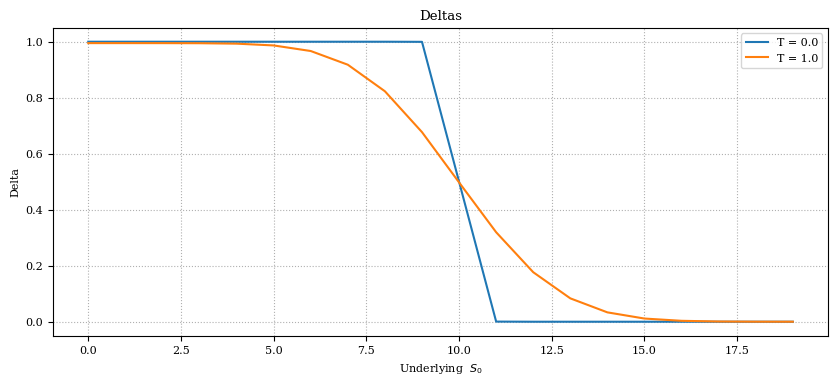

In [ ]:
fig = plt.figure(figsize=(10,4))
for i in range(0, deltas.shape[0], 10):
    plt.plot(deltas[i,:], label = f'T = {i/10}')
plt.xlabel("Underlying  $S_0$")
plt.ylabel('Delta')
plt.grid(linestyle=":")
plt.legend()
plt.title('Deltas')
plt.show()

/tmp/ipykernel_80266/299776829.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/sushi/miniconda3/envs/finance/lib/python3.13/site-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/sushi/miniconda3/envs/finance/lib/python3.13/site-packages/matplotlib/cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


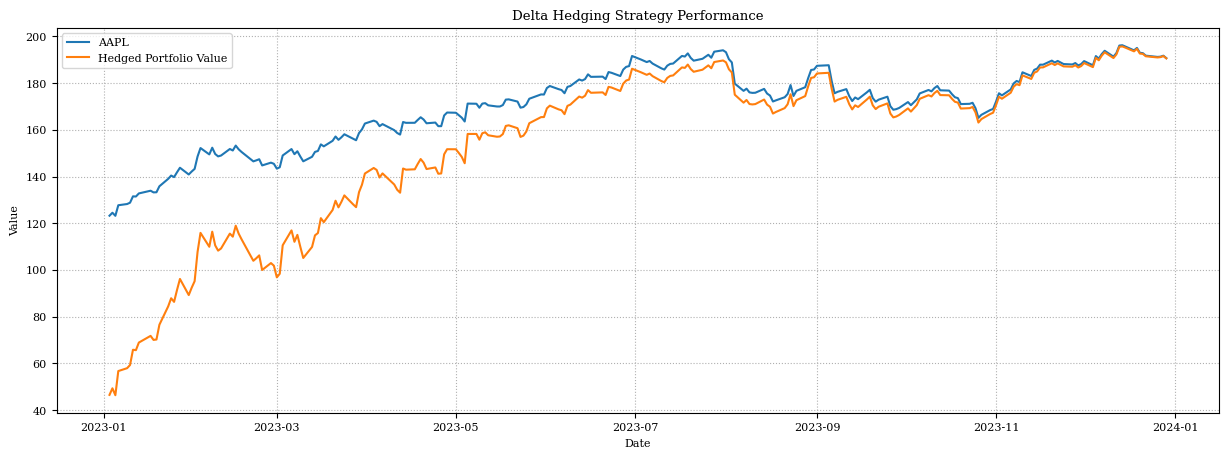

In [ ]:
import yfinance as yf


def fetch_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

def delta_hedging(stock_data, K, T, r, sigma):
    hedge_positions = []
    portfolio_values = []
    previous_delta = 0
    
    for index, row in stock_data.iterrows():
        S = row['Close']
        current_delta = delta(S, K, T, r, sigma)
        shares_to_trade = current_delta - previous_delta
        hedge_positions.append(shares_to_trade)
        portfolio_value = current_delta * S
        portfolio_values.append(portfolio_value)
        previous_delta = current_delta
        
        T -= 1 / 252
    
    stock_data['Hedge Positions'] = hedge_positions
    stock_data['Portfolio Value'] = portfolio_values
    return stock_data


ticker = 'AAPL'
start_date = '2023-01-01'
end_date = '2023-12-31'
strike_price = 130
time_to_expiration = 1.0
risk_free_rate = 0.05
volatility = 0.2


data = fetch_data(ticker, start_date, end_date)
hedged_data = delta_hedging(data, strike_price, time_to_expiration, risk_free_rate, volatility)


plt.figure(figsize=(15, 5))
plt.plot(hedged_data.index, hedged_data['Close'], label=ticker)
plt.plot(hedged_data.index, hedged_data['Portfolio Value'], label='Hedged Portfolio Value')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.title('Delta Hedging Strategy Performance')
plt.grid(linestyle=":")
plt.show()

In [ ]:
import yfinance as yf

data = yf.Ticker('AAPL')
print(data.options)
data.option_chain('2026-01-16').calls

('2026-01-09', '2026-01-16', '2026-01-23', '2026-01-30', '2026-02-06', '2026-02-13', '2026-02-20', '2026-03-20', '2026-04-17', '2026-05-15', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-12-18', '2027-01-15', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17')


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260116C00005000,2026-01-07 15:56:16+00:00,5.0,257.25,250.05,253.30,0.0,0.0,8.0,58,11.453128,True,REGULAR,USD
1,AAPL260116C00010000,2026-01-05 14:36:05+00:00,10.0,258.39,244.90,248.70,0.0,0.0,4.0,29,9.679691,True,REGULAR,USD
2,AAPL260116C00015000,2026-01-02 14:39:25+00:00,15.0,259.24,239.90,243.70,0.0,0.0,4.0,2,8.320317,True,REGULAR,USD
3,AAPL260116C00020000,2026-01-02 14:39:25+00:00,20.0,254.23,235.15,238.70,0.0,0.0,4.0,138,7.734375,True,REGULAR,USD
4,AAPL260116C00025000,2025-12-22 18:27:04+00:00,25.0,245.99,229.90,233.55,0.0,0.0,2.0,15,6.500002,True,REGULAR,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,AAPL260116C00410000,2025-12-17 18:57:15+00:00,410.0,0.01,0.00,0.01,0.0,0.0,1.0,298,0.906251,False,REGULAR,USD
86,AAPL260116C00420000,2025-12-10 20:36:26+00:00,420.0,0.01,0.00,0.01,0.0,0.0,1.0,1650,0.937501,False,REGULAR,USD
87,AAPL260116C00430000,2025-12-17 18:57:15+00:00,430.0,0.01,0.00,0.01,0.0,0.0,1.0,721,0.968750,False,REGULAR,USD
88,AAPL260116C00440000,2025-12-22 18:19:19+00:00,440.0,0.01,0.00,0.01,0.0,0.0,3.0,4087,1.015630,False,REGULAR,USD


In [ ]:
import yfinance as yf

stock_data = yf.Ticker(ticker)
stock_data.history(period='1y')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-01-08 00:00:00-05:00,240.830782,242.612732,238.969207,241.607269,37628900,0.0,0.0
2025-01-10 00:00:00-05:00,238.929361,239.078694,231.950928,235.783600,61710900,0.0,0.0
2025-01-13 00:00:00-05:00,232.478557,233.613424,228.685713,233.344635,49630700,0.0,0.0
2025-01-14 00:00:00-05:00,233.693073,235.056900,231.423340,232.229691,39435300,0.0,0.0
2025-01-15 00:00:00-05:00,233.583558,237.884115,233.374497,236.799011,39832000,0.0,0.0
...,...,...,...,...,...,...,...
2026-01-02 00:00:00-05:00,272.260010,277.839996,269.000000,271.010010,37838100,0.0,0.0
2026-01-05 00:00:00-05:00,270.640015,271.510010,266.140015,267.260010,45647200,0.0,0.0
2026-01-06 00:00:00-05:00,267.000000,267.549988,262.119995,262.359985,52352100,0.0,0.0


In [ ]:
# Importing necessary libraries
import yfinance as yf  # For fetching financial data
import pandas as pd  # For data manipulation
import numpy as np  # For numerical calculations
import scipy as sp  # For scientific computing
import matplotlib.pyplot as plt  # For plotting
from datetime import datetime  # For handling dates
from scipy.optimize import fsolve  # For solving equations
from scipy.stats import norm  # For normal distribution

# Suppressing warnings related to iteration progress
# import warnings
# warnings.filterwarnings('ignore', 'The iteration is not making good progress')

# Getting today's date
today = datetime.now()

def vol_nappe(sj, r, our_type, sigma) :
    sj = sj  # Ticker symbol
    r = r  # Risk-free rate

    # Downloading historical data to get S0
    start_date = today.strftime('%Y-%m-%d')
    stock_data = yf.download(sj, start=start_date)
    S0 = stock_data['Close'].iloc[-1,0]

    print(S0)
    option_data = yf.Ticker(sj)
    option_datas = option_data.options

    df_option_data = []

    # Iterating through option data for different expiration dates
    for expiration_date in option_datas:
        option_chain = option_data.option_chain(expiration_date)
        
        calls = option_chain.calls
        puts = option_chain.puts
        
        # Extracting call options data
        for option in calls.iterrows():
            strike = option[1]['strike']
            midprice = (option[1]['bid'] + option[1]['ask']) / 2
            df_option_data.append([expiration_date, strike, midprice, 'CALL'])

        # Extracting put options data
        for option in puts.iterrows():
            strike = option[1]['strike']
            midprice = (option[1]['bid'] + option[1]['ask']) / 2
            df_option_data.append([expiration_date, strike, midprice, 'PUT'])

    df_option_data = pd.DataFrame(df_option_data, columns=['expiration_date', 'strike', 'midprice', 'type'])
    df_option_data = df_option_data[(S0 * 0.8 < df_option_data['strike']) & (df_option_data['strike'] < S0 * 1.2)]

    df_option_data['days_to_expiry'] = df_option_data['expiration_date']
    df_option_data['days_to_expiry'] = pd.to_datetime(df_option_data['days_to_expiry'])
    
    df_option_data['expiration_date'] = (df_option_data['days_to_expiry'] - today).dt.days

    df_option_data = df_option_data[df_option_data['expiration_date'] > 0]
    df_option_data = df_option_data[df_option_data['expiration_date'] < 100]  # Filter expiration dates so they are not too far in the future
    df_option_data = df_option_data.set_index(['expiration_date', 'strike', 'type']).sort_index()

    df_option_data = df_option_data.pivot_table(index=['expiration_date', 'strike'], columns='type', values='midprice')

    # Black-Scholes-Merton (BSM) formula for option pricing
    def BSM(sigma, S0, K, P, T, r, type_) : 
        d1 = (np.log(S0/K) + (r+sigma**2/2)*T)/(sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        if type_ == 'CALL' : 
            return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2) - P
        elif type_ == 'PUT' : 
            return K * np.exp(-r * T) * norm.cdf(-d2) - P - S0 * norm.cdf(-d1) 

    imp_vol_df = []
    # Calculating implied volatility using BSM formula
    for index, value in df_option_data[our_type].items():
        T = index[0] / 365
        K = index[1]
        sigma0 = sigma  # Initial value of sigma 
        imp_vol = fsolve(BSM, sigma0, args=(S0, K, value, T, r, our_type))
        imp_vol_scalar = float(imp_vol[0])
        imp_vol_df.append(imp_vol_scalar)

    imp_vol_df_indexed = pd.Series(imp_vol_df, index=df_option_data[our_type].index)

    df_interpolated = imp_vol_df_indexed.unstack(0).interpolate(method='linear')

    # Creating a 3D plot of the volatility surface
    x, y = np.meshgrid(np.array(df_option_data[our_type].index.levels[0]), np.array(df_option_data[our_type].index.get_level_values(1).unique()))
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(x, y, np.array(df_interpolated), cmap='plasma')

    plt.xlabel("Maturity")
    plt.ylabel("Strike")
    ax.set_zlabel("Volatility")

    fig.colorbar(surf)

    plt.show()

vol_nappe('NVDA', 0.01, 'CALL', sigma)

/tmp/ipykernel_80266/1149065939.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(sj, start=start_date)
[*********************100%***********************]  1 of 1 completed


IndexError: index -1 is out of bounds for axis 0 with size 0

/tmp/ipykernel_1629/2689488404.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


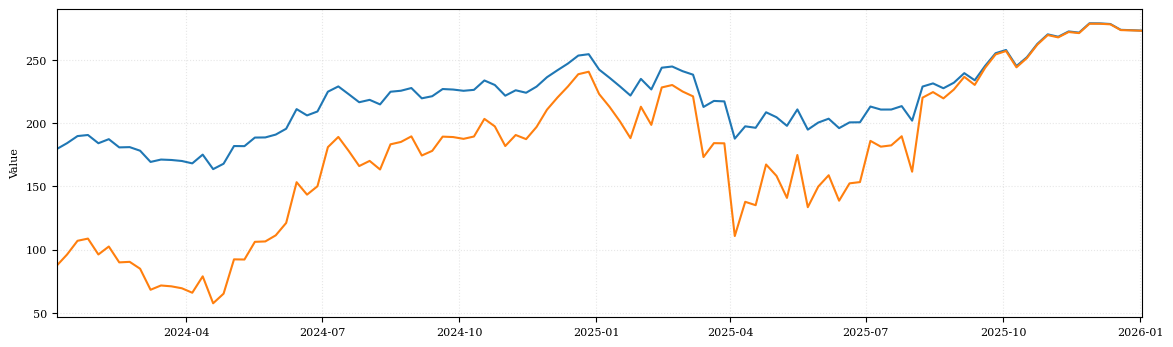

Approximate price of Option: 
Strike price:  180.0
Final Price:  273.0799865722656
Cost of hedging:  217.78051715577857
Option price =  37.40645262948373
Call option BS =  14.893201051429983


In [ ]:
import yfinance as yf

ticker = 'AAPL'
start_date = '2024-01-01'
end_date = '2025-12-31'
data = yf.download(ticker, start_date, end_date)

nb_contracts = 100
K = 180
T = 2.0
r = 0.01
sigma = 0.2

def delta(S, K, T, r, sigma):
    d1 = (np.log(S/K) + T*(r*sigma**2 / 2)) / (sigma * np.sqrt(T))
    deltaCall = np.exp(-r*T)*norm.cdf(d1)
    return deltaCall

stock_price_weekly = data['Close'].resample('W-FRI').last()
hedge_positions = []
portfolio_values = []
cumulative_cost = []
interest_borrow = []
previous_delta = 0

for i, S in stock_price_weekly.iterrows():
    S = S.iloc[0]
    current_delta = delta(S, K, T, r, sigma).item()
    share_to_trade = current_delta - previous_delta
    hedge_positions.append(current_delta)
    portfolio_values.append(current_delta * S)

    if cumulative_cost:
        interest_cost = (cumulative_cost[-1] + share_to_trade*S)*(r/52)
        cumulative_cost.append(cumulative_cost[-1] + share_to_trade*S + last_interest_cost)
    else:
        interest_cost = share_to_trade*S*(r/52)
        cumulative_cost.append(share_to_trade*S)
    interest_borrow.append(interest_cost)

    last_interest_cost=interest_cost
    previous_delta = current_delta
    T -= 1/53

final_data = stock_price_weekly.copy()

final_data['Delta'] = hedge_positions
final_data['Portfolio Value'] = portfolio_values
final_data['Cumulative Cost'] = cumulative_cost
final_data['Interest Cost'] = interest_borrow

final_data
plt.figure(figsize=(14,4))
plt.plot(stock_price_weekly.index, stock_price_weekly)
plt.plot(stock_price_weekly.index, portfolio_values)
plt.ylabel("Value")
plt.grid(linestyle=':', alpha=0.3)
plt.margins(x=0)
plt.show()

final_data.tail()

# print(stock_price_weekly.iloc[-1].values)
# BS_CALL(stock_price_weekly.iloc[-1].values, K, 1.0, r, sigma)
final_price = stock_price_weekly.iloc[-1].values[0]
final_cum_cost = final_data['Cumulative Cost'].iloc[-1]
print("Approximate price of Option: ")
print("Strike price: ", K + 0.0)
print("Final Price: ", final_price)
print("Cost of hedging: ", final_data['Cumulative Cost'].iloc[-1])
print("Option price = ", ((final_cum_cost - K if K<final_price else final_cum_cost)) * (1+r)**(-1.0) )

print("Call option BS = ", BS_CALL(stock_price_weekly.iloc[0].values, K, 1.0, r, sigma)[0])

In [ ]:
final_data

Ticker,AAPL,Delta,Portfolio Value,Cumulative Cost,Interest Cost
Date,,,,,
2024-01-05,179.484955,0.486691,87.353670,87.353670,0.016799
2024-01-12,184.180618,0.522605,96.253756,93.985219,0.018071
2024-01-19,189.767822,0.564174,107.062112,101.891743,0.019591
2024-01-26,190.619812,0.570792,108.804287,103.172839,0.019837
2024-02-02,184.111282,0.522828,96.258602,94.362008,0.018143
...,...,...,...,...,...
2025-12-05,278.779999,0.998869,278.464577,217.406111,0.041801
2025-12-12,278.279999,0.999057,278.017594,217.500363,0.041819
2025-12-19,273.670013,0.999246,273.463548,217.593774,0.041837


### Golden Cross Indicator

A golden cross is a bullish chart pattern where a shorter-term moving average (most commonly the 50‑day) crosses above a longer‑term moving average (typically the 200‑day) on a price chart. Traders see this as a sign that recent price momentum has turned strong enough to overcome the longer‑term trend and that a longer‑lasting uptrend may be starting.

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt

ticker = 'NVDA'
start_date = '2024-01-01'
end_date = '2025-12-31'
data = yf.download(ticker, start_date, end_date)

/tmp/ipykernel_1742/111780975.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed


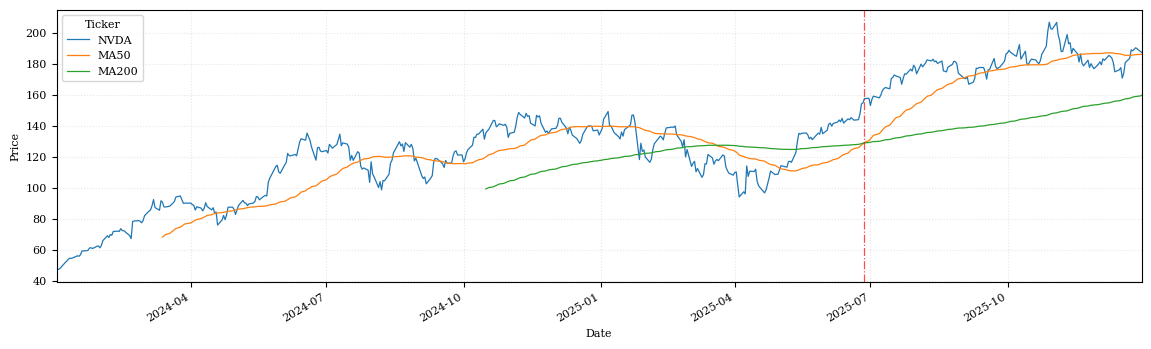

In [ ]:
data

xx = data.Close
xx = xx.assign(
    MA50 = lambda x: x.iloc[:,0].rolling(50).mean(),
    MA200 = lambda x: x.iloc[:,0].rolling(200).mean(),
    CROSS = lambda x: (x.MA50.shift(1) < x.MA200.shift(1)) & (x.MA50 >= x.MA200)
)


# xx = xx.copy()
# xx['MA50'] = xx.iloc[:,0].rolling(50).mean()
# xx['MA200'] = xx.iloc[:,0].rolling(200).mean()
# xx['CROSS'] = (xx['MA50'].shift(1) < xx['MA200'].shift(1)) & (xx['MA50'] >= xx['MA200'])

xx.plot(figsize=(14, 4), linewidth=0.9)
plt.ylabel('Price')
if sum(xx.CROSS) > 0:
    [plt.axvline(x=i, c='r', linestyle='-.', linewidth=0.9, alpha=0.7) for i in xx.CROSS.index[xx.CROSS==True]]
plt.grid(linestyle=':', alpha=0.3)
plt.margins(x=0)
plt.show()

## Put Call Parity

Put call parity is given by
\begin{equation}
    P + S_T = C + K*\exp{-rT}
\end{equation}

